# 第 12 章 · 冰湖导航 MCTS 规划代码实验

本页让智能体从起点反复模拟未来路线。每个动作会因为滑动到达不同格子，MCTS 会在平均回报和探索项之间分配模拟次数。

[章节网页](../ch12.html)

## 运行内容

- 查看起点候选动作
- 反复模拟候选路线
- 展开下一状态候选
- 绘制访问价值

## 0. 从起点规划动作

先看起点的候选动作、滑动概率和一步期望得分。得分由步进代价、靠近终点的进度、掉洞惩罚和到达奖励共同决定，用来让中间状态也能比较好坏。

In [1]:
# 载入本页会用到的数据集、模型和绘图工具。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display
from scipy.signal import correlate2d
from sklearn.datasets import load_breast_cancer, load_digits, load_iris, load_sample_image, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

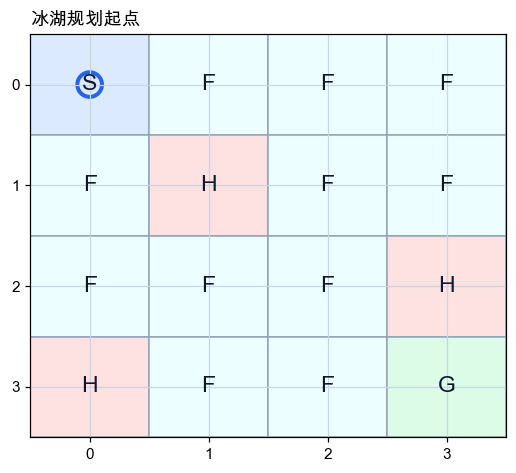

,得分来源,作用,数值
0,每走一步,鼓励更短路线,-0.02
1,靠近终点,让中间状态也能比较好坏,+0.10 × 距离缩短
2,到达终点,明确最终目标,+1.20
3,掉入洞中,惩罚危险路线,-0.35


,当前状态,候选动作,一步期望得分,掉洞概率,到达概率,可能到达
0,"S(0,0)",左,-0.008,0,0,"0.76→S(0,0) / 0.12→S(0,0) / 0.12→F(1,0)"
1,"S(0,0)",下,0.068,0,0,"0.76→F(1,0) / 0.12→S(0,0) / 0.12→F(0,1)"
2,"S(0,0)",右,0.068,0,0,"0.76→F(0,1) / 0.12→F(1,0) / 0.12→S(0,0)"
3,"S(0,0)",上,-0.008,0,0,"0.76→S(0,0) / 0.12→F(0,1) / 0.12→S(0,0)"


,当前状态,候选动作,实际结果,可能到达,概率,即时得分,是否结束
0,"S(0,0)",左,按计划,"S(0,0)",0.76,-0.02,False
1,"S(0,0)",左,滑向侧边,"S(0,0)",0.12,-0.02,False
2,"S(0,0)",左,滑向侧边,"F(1,0)",0.12,0.08,False
3,"S(0,0)",下,按计划,"F(1,0)",0.76,0.08,False
4,"S(0,0)",下,滑向侧边,"S(0,0)",0.12,-0.02,False
5,"S(0,0)",下,滑向侧边,"F(0,1)",0.12,0.08,False
6,"S(0,0)",右,按计划,"F(0,1)",0.76,0.08,False
7,"S(0,0)",右,滑向侧边,"F(1,0)",0.12,0.08,False
8,"S(0,0)",右,滑向侧边,"S(0,0)",0.12,-0.02,False
9,"S(0,0)",上,按计划,"S(0,0)",0.76,-0.02,False


In [2]:
# MCTS 先从起点看候选动作，再用模拟逐步判断哪个动作更值得走。
mcts_map = np.array([
    list("SFFF"),
    list("FHFF"),
    list("FFFH"),
    list("HFFG"),
])
n_rows, n_cols = mcts_map.shape
mcts_actions = {0: "左", 1: "下", 2: "右", 3: "上"}
mcts_arrows = {0: "←", 1: "↓", 2: "→", 3: "↑"}
action_delta = {0: (0, -1), 1: (1, 0), 2: (0, 1), 3: (-1, 0)}
side_actions = {0: (3, 1), 1: (0, 2), 2: (1, 3), 3: (2, 0)}
root_state = 0
goal_state = int(np.flatnonzero(mcts_map.reshape(-1) == "G")[0])

def state_to_rc(state):
    return divmod(int(state), n_cols)


def rc_to_state(row, col):
    return int(row * n_cols + col)


def state_name(state):
    row, col = state_to_rc(state)
    return f"{mcts_map[row, col]}({row},{col})"


def goal_distance(state):
    row, col = state_to_rc(state)
    goal_row, goal_col = state_to_rc(goal_state)
    return abs(row - goal_row) + abs(col - goal_col)


def move_state(state, action):
    row, col = state_to_rc(state)
    dr, dc = action_delta[action]
    next_row = min(max(row + dr, 0), n_rows - 1)
    next_col = min(max(col + dc, 0), n_cols - 1)
    return rc_to_state(next_row, next_col)


def mcts_step_model(state, action):
    tile = mcts_map[state_to_rc(state)]
    if tile in {"H", "G"}:
        return [(1.0, state, 0.0, True, "已结束")]

    candidates = [(action, 0.76, "按计划")] + [(a, 0.12, "滑向侧边") for a in side_actions[action]]
    outcomes = []
    old_dist = goal_distance(state)
    for actual_action, prob, cause in candidates:
        next_state = move_state(state, actual_action)
        next_tile = mcts_map[state_to_rc(next_state)]
        progress = 0.10 * (old_dist - goal_distance(next_state))
        reward = -0.02 + progress
        done = next_tile in {"H", "G"}
        if next_tile == "G":
            reward += 1.2
        elif next_tile == "H":
            reward -= 0.35
        outcomes.append((prob, next_state, reward, done, cause))
    return outcomes


def action_candidate_table(state):
    rows = []
    for action in mcts_actions:
        outcomes = mcts_step_model(state, action)
        expected_reward = sum(prob * reward for prob, _, reward, _, _ in outcomes)
        hole_risk = sum(prob for prob, next_state, _, _, _ in outcomes if mcts_map[state_to_rc(next_state)] == "H")
        goal_chance = sum(prob for prob, next_state, _, _, _ in outcomes if mcts_map[state_to_rc(next_state)] == "G")
        rows.append({
            "当前状态": state_name(state),
            "候选动作": mcts_actions[action],
            "一步期望得分": expected_reward,
            "掉洞概率": hole_risk,
            "到达概率": goal_chance,
            "可能到达": " / ".join(f"{prob:.2f}→{state_name(next_state)}" for prob, next_state, _, _, _ in outcomes),
        })
    return pd.DataFrame(rows)


def transition_detail_table(state):
    rows = []
    for action in mcts_actions:
        for prob, next_state, reward, done, cause in mcts_step_model(state, action):
            rows.append({
                "当前状态": state_name(state),
                "候选动作": mcts_actions[action],
                "实际结果": cause,
                "可能到达": state_name(next_state),
                "概率": prob,
                "即时得分": reward,
                "是否结束": done,
            })
    return pd.DataFrame(rows)


def draw_mcts_lake(ax, title, highlight_state=None, path_states=None):
    tile_color = {"S": "#dbeafe", "F": "#ecfeff", "H": "#fee2e2", "G": "#dcfce7"}
    path_states = set(path_states or [])
    for row in range(n_rows):
        for col in range(n_cols):
            state = rc_to_state(row, col)
            tile = mcts_map[row, col]
            ax.add_patch(plt.Rectangle((col - 0.5, row - 0.5), 1, 1, color=tile_color[tile], ec="#94a3b8"))
            ax.text(col, row, tile, ha="center", va="center", fontsize=15, fontweight="bold", color="#0f172a")
            if state in path_states:
                ax.add_patch(plt.Rectangle((col - 0.42, row - 0.42), 0.84, 0.84, fill=False, ec="#f97316", lw=2.4))
    if highlight_state is not None:
        row, col = state_to_rc(highlight_state)
        ax.scatter([col], [row], s=260, facecolors="none", edgecolors="#2563eb", linewidths=2.6)
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xlim(-0.5, n_cols - 0.5)
    ax.set_ylim(n_rows - 0.5, -0.5)
    ax.set_xticks(range(n_cols))
    ax.set_yticks(range(n_rows))
    ax.grid(True, color="#cbd5e1", linewidth=0.8)

fig, ax = plt.subplots(figsize=(4.8, 4.4))
draw_mcts_lake(ax, "冰湖规划起点", highlight_state=root_state)
plt.tight_layout()
plt.show()

display(pd.DataFrame([
    {"得分来源": "每走一步", "作用": "鼓励更短路线", "数值": "-0.02"},
    {"得分来源": "靠近终点", "作用": "让中间状态也能比较好坏", "数值": "+0.10 × 距离缩短"},
    {"得分来源": "到达终点", "作用": "明确最终目标", "数值": "+1.20"},
    {"得分来源": "掉入洞中", "作用": "惩罚危险路线", "数值": "-0.35"},
]))
display(action_candidate_table(root_state).round(3))
display(transition_detail_table(root_state).round(3))

## 1. 模拟与展开

MCTS 会反复抽样未来路线。根节点表格展示动作访问次数和平均回报，下一状态表格展示推荐动作落到新格子之后如何继续选择。

In [3]:
# 运行 UCT：平均回报代表动作已有表现，探索项代表还值得继续试探。
rng = np.random.default_rng(12)
N_state = defaultdict(int)
N_action = defaultdict(int)
W_action = defaultdict(float)

def sample_model_step(state, action):
    outcomes = mcts_step_model(state, action)
    probs = np.array([item[0] for item in outcomes], dtype=float)
    probs = probs / probs.sum()
    idx = rng.choice(len(outcomes), p=probs)
    prob, next_state, reward, done, _ = outcomes[idx]
    return next_state, reward, done


def uct_action(state, c=1.4):
    for action in mcts_actions:
        if N_action[(state, action)] == 0:
            return action
    scores = []
    for action in mcts_actions:
        mean_value = W_action[(state, action)] / N_action[(state, action)]
        explore = c * np.sqrt(np.log(N_state[state] + 1) / N_action[(state, action)])
        scores.append(mean_value + explore)
    return int(np.argmax(scores))


def rollout_action(state):
    scores = []
    for action in mcts_actions:
        outcomes = mcts_step_model(state, action)
        scores.append(sum(prob * reward for prob, _, reward, _, _ in outcomes))
    scores = np.array(scores)
    weights = np.exp((scores - scores.max()) * 5.0)
    weights = weights / weights.sum()
    return int(rng.choice(list(mcts_actions.keys()), p=weights))


def rollout(state, depth_limit=18, gamma=0.99):
    total = 0.0
    discount = 1.0
    for _ in range(depth_limit):
        action = rollout_action(state)
        state, reward, done = sample_model_step(state, action)
        total += discount * reward
        discount *= gamma
        if done:
            break
    return total


simulation_rows = []
early_simulation_rows = []
for simulation in range(1, 1001):
    state = root_state
    path = []
    path_states = [root_state]
    path_actions = []
    total_reward = 0.0
    discount = 1.0
    done = False
    for depth in range(18):
        action = uct_action(state)
        path.append((state, action))
        path_actions.append(mcts_actions[action])
        next_state, reward, done = sample_model_step(state, action)
        total_reward += discount * reward
        discount *= 0.99
        state = next_state
        path_states.append(state)
        if done:
            break
    if not done:
        total_reward += discount * rollout(state)

    if simulation <= 8:
        early_simulation_rows.append({
            "模拟轮次": simulation,
            "动作序列": " → ".join(path_actions[:8]),
            "状态序列": " → ".join(state_name(s) for s in path_states[:9]),
            "累计回报": total_reward,
        })

    for state, action in path:
        N_state[state] += 1
        N_action[(state, action)] += 1
        W_action[(state, action)] += total_reward
    if simulation % 200 == 0:
        simulation_rows.append({"simulation": simulation, "root_visits": N_state[root_state]})

root_rows = []
for action in mcts_actions:
    visits = N_action[(root_state, action)]
    mean_value = W_action[(root_state, action)] / visits if visits else 0
    explore = 1.4 * np.sqrt(np.log(N_state[root_state] + 1) / visits) if visits else 0
    root_rows.append({
        "action_id": action,
        "action": mcts_actions[action],
        "visits": visits,
        "mean_value": mean_value,
        "explore": explore,
        "UCT": mean_value + explore,
    })

mcts_root_df = pd.DataFrame(root_rows).sort_values("UCT", ascending=False).reset_index(drop=True)
mcts_sim_df = pd.DataFrame(simulation_rows)
display(pd.DataFrame(early_simulation_rows).round(4))
display(mcts_root_df.rename(columns={
    "action_id": "动作编号",
    "action": "动作",
    "visits": "访问次数",
    "mean_value": "平均回报",
    "explore": "探索项",
}).round(4))
print("起点推荐动作:", mcts_root_df.loc[0, "action"])

,模拟轮次,动作序列,状态序列,累计回报
0,1,左 → 左 → 左 → 左 → 左 → 左 → 左 → 左,"S(0,0) → S(0,0) → F(1,0) → F(1,0) → F(1,0) → F...",-0.3721
1,2,下 → 下,"S(0,0) → F(1,0) → H(1,1)",-0.1873
2,3,右 → 右 → 右 → 左,"S(0,0) → S(0,0) → S(0,0) → F(0,1) → H(1,1)",-0.2234
3,4,上 → 上 → 下,"S(0,0) → S(0,0) → F(0,1) → H(1,1)",-0.2054
4,5,下 → 右 → 下,"S(0,0) → F(1,0) → F(2,0) → H(3,0)",-0.1054
5,6,下 → 下 → 上 → 下 → 下 → 上 → 上 → 下,"S(0,0) → S(0,0) → F(1,0) → S(0,0) → S(0,0) → F...",-0.3444
6,7,上 → 上 → 上 → 上 → 上 → 上 → 上 → 上,"S(0,0) → S(0,0) → F(0,1) → F(0,1) → F(0,1) → F...",-0.4841
7,8,左 → 左 → 左 → 左 → 左 → 左 → 左 → 左,"S(0,0) → S(0,0) → S(0,0) → S(0,0) → S(0,0) → S...",-0.3770


,动作编号,动作,访问次数,平均回报,探索项,UCT
0,1,下,1173,0.7737,0.1102,0.8839
1,2,右,136,-0.1972,0.3236,0.1264
2,0,左,67,-0.3604,0.4611,0.1007
3,3,上,56,-0.4179,0.5043,0.0864


起点推荐动作: 下


,起点动作,最可能下一状态,该步概率,即时得分,是否结束
0,下,"F(1,0)",0.76,0.08,False


,当前状态,候选动作,一步期望得分,掉洞概率,到达概率,可能到达
0,"F(1,0)",下,0.026,0.12,0,"0.76→F(2,0) / 0.12→F(1,0) / 0.12→H(1,1)"
1,"F(1,0)",左,-0.020,0.00,0,"0.76→F(1,0) / 0.12→S(0,0) / 0.12→F(2,0)"
2,"F(1,0)",上,-0.126,0.12,0,"0.76→S(0,0) / 0.12→H(1,1) / 0.12→F(1,0)"
3,"F(1,0)",右,-0.210,0.76,0,"0.76→H(1,1) / 0.12→F(2,0) / 0.12→S(0,0)"


,当前状态,候选动作,实际结果,可能到达,概率,即时得分,是否结束
0,"F(1,0)",左,按计划,"F(1,0)",0.76,-0.02,False
1,"F(1,0)",左,滑向侧边,"S(0,0)",0.12,-0.12,False
2,"F(1,0)",左,滑向侧边,"F(2,0)",0.12,0.08,False
3,"F(1,0)",下,按计划,"F(2,0)",0.76,0.08,False
4,"F(1,0)",下,滑向侧边,"F(1,0)",0.12,-0.02,False
5,"F(1,0)",下,滑向侧边,"H(1,1)",0.12,-0.27,True
6,"F(1,0)",右,按计划,"H(1,1)",0.76,-0.27,True
7,"F(1,0)",右,滑向侧边,"F(2,0)",0.12,0.08,False
8,"F(1,0)",右,滑向侧边,"S(0,0)",0.12,-0.12,False
9,"F(1,0)",上,按计划,"S(0,0)",0.76,-0.12,False


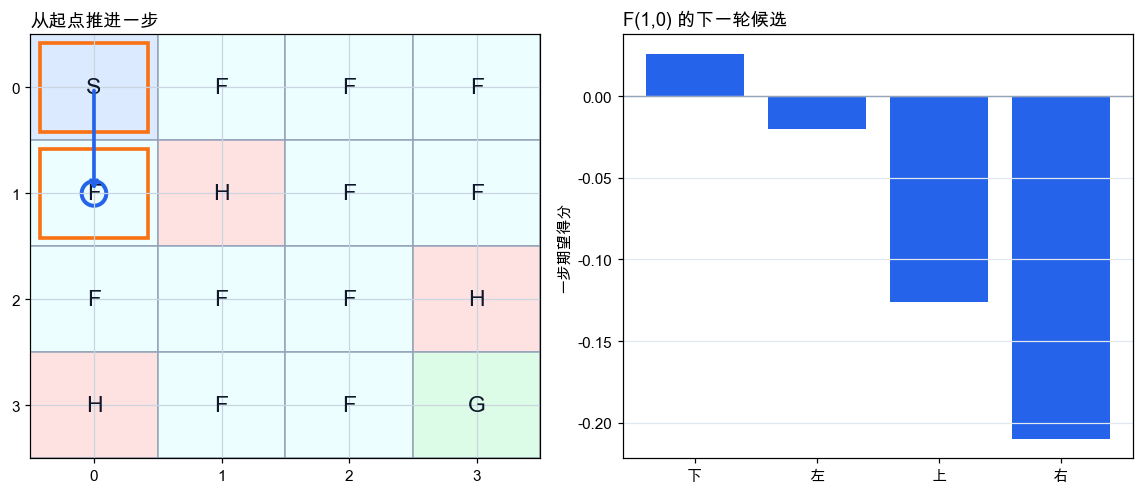

In [4]:
# 沿着根节点推荐动作走一步，再查看新状态的候选动作。
best_root_action = int(mcts_root_df.loc[0, "action_id"])
best_outcomes = mcts_step_model(root_state, best_root_action)
safe_outcomes = [item for item in best_outcomes if mcts_map[state_to_rc(item[1])] != "H"]
next_prob, next_state, next_reward, next_done, _ = max(safe_outcomes, key=lambda item: (item[0], item[2]))
next_candidates = action_candidate_table(next_state).sort_values("一步期望得分", ascending=False).reset_index(drop=True)

display(pd.DataFrame([{
    "起点动作": mcts_actions[best_root_action],
    "最可能下一状态": state_name(next_state),
    "该步概率": next_prob,
    "即时得分": next_reward,
    "是否结束": next_done,
}]).round(3))
display(next_candidates.round(3))
display(transition_detail_table(next_state).round(3))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.6))
draw_mcts_lake(axes[0], "从起点推进一步", highlight_state=next_state, path_states=[root_state, next_state])
root_r, root_c = state_to_rc(root_state)
next_r, next_c = state_to_rc(next_state)
axes[0].annotate("", xy=(next_c, next_r), xytext=(root_c, root_r), arrowprops={"arrowstyle": "->", "lw": 2.4, "color": "#2563eb"})

axes[1].bar(next_candidates["候选动作"], next_candidates["一步期望得分"], color="#2563eb")
axes[1].axhline(0, color="#94a3b8", linewidth=0.9)
axes[1].set_title(f"{state_name(next_state)} 的下一轮候选", loc="left", fontweight="bold")
axes[1].set_ylabel("一步期望得分")
axes[1].grid(True, axis="y", color="#e2e8f0", linewidth=0.8)
plt.tight_layout()
plt.show()

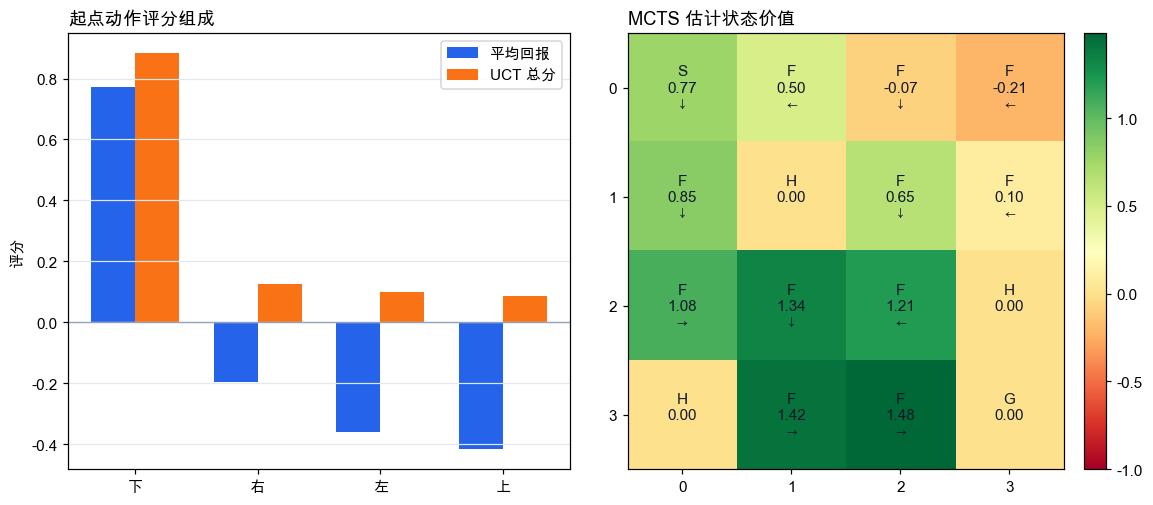

In [5]:
# 绘制根节点动作统计和 MCTS 访问到的状态价值。
fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.7))
x = np.arange(len(mcts_root_df))
axes[0].bar(x - 0.18, mcts_root_df["mean_value"], width=0.36, color="#2563eb", label="平均回报")
axes[0].bar(x + 0.18, mcts_root_df["UCT"], width=0.36, color="#f97316", label="UCT 总分")
axes[0].set_xticks(x, mcts_root_df["action"])
axes[0].set_title("起点动作评分组成", loc="left", fontweight="bold")
axes[0].set_ylabel("评分")
axes[0].axhline(0, color="#94a3b8", linewidth=0.9)
axes[0].grid(True, axis="y", color="#e2e8f0", linewidth=0.8)
axes[0].legend()

state_count = n_rows * n_cols
value_grid = np.zeros(state_count)
policy_grid = np.full(state_count, -1)
for state in range(state_count):
    values = []
    for action in mcts_actions:
        visits = N_action[(state, action)]
        values.append(W_action[(state, action)] / visits if visits else np.nan)
    if not np.all(np.isnan(values)):
        policy_grid[state] = int(np.nanargmax(values))
        value_grid[state] = float(np.nanmax(values))
value_grid = value_grid.reshape(n_rows, n_cols)
policy_grid = policy_grid.reshape(n_rows, n_cols)

im = axes[1].imshow(value_grid, cmap="RdYlGn", vmin=min(-1.0, value_grid.min()), vmax=max(1.0, value_grid.max()))
for state in range(state_count):
    r, c = state_to_rc(state)
    tile = mcts_map[r, c]
    arrow = "" if tile in {"H", "G"} or policy_grid[r, c] < 0 else mcts_arrows[int(policy_grid[r, c])]
    axes[1].text(c, r, f"{tile}\n{value_grid[r, c]:.2f}\n{arrow}", ha="center", va="center", color="#0f172a", fontweight="bold")
axes[1].set_title("MCTS 估计状态价值", loc="left", fontweight="bold")
axes[1].set_xticks(range(n_cols))
axes[1].set_yticks(range(n_rows))
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()